In [1]:
%pip install pdfplumber


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pdfplumber
with pdfplumber.open('lab_8_paragragh.pdf') as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        print("Raw Text:\n",text)

Raw Text:
 The Forgotten Soldier
Author:
John R. Donovan is a renowned author with a passion for historical fiction, having
written over thirty books, including War Stories, The Last Patrol, Escape from the
Frontlines, and A Soldier’s Journey. His works are known for their vivid storytelling and
meticulous attention to historical detail. He resides in Seattle, Washington, where he
continues to explore the untold stories of the past.
This novel is inspired by true events that unfolded during the brutal winter of 1943, when
a young soldier found himself trapped behind enemy lines. Facing unimaginable odds,
he had to rely on his wits, courage, and an unlikely friendship to survive in a war-torn
land.


In [3]:
import spacy
nlp = spacy.load('en_core_web_sm')
doc = nlp(text)
cleaned_text = ' '.join([token.text for token in doc if not token.is_stop and not
token.is_punct])
print("Cleaned Tect:\n",cleaned_text)

Cleaned Tect:
 Forgotten Soldier 
 Author 
 John R. Donovan renowned author passion historical fiction having 
 written thirty books including War Stories Patrol Escape 
 Frontlines Soldier Journey works known vivid storytelling 
 meticulous attention historical detail resides Seattle Washington 
 continues explore untold stories past 
 novel inspired true events unfolded brutal winter 1943 
 young soldier found trapped enemy lines Facing unimaginable odds 
 rely wits courage unlikely friendship survive war torn 
 land


In [4]:
doc = nlp(cleaned_text)
print("Entities:\n")
for ent in doc.ents:
    print(ent.text, ent.label_)

Entities:

Forgotten Soldier 
 Author PERSON
John R. Donovan PERSON
thirty CARDINAL
War Stories Patrol Escape 
 Frontlines ORG
Soldier Journey PERSON
Washington 
  GPE
winter 1943 DATE


In [5]:
from transformers import BertTokenizer, BertForTokenClassification
from transformers import pipeline
tokenizer = BertTokenizer.from_pretrained('dslim/bert-base-NER')
model = BertForTokenClassification.from_pretrained('dslim/bert-base-NER')
nlp_ner = pipeline('ner', model=model, tokenizer=tokenizer)
ner_results = nlp_ner(cleaned_text)
import json
output = {
"Entities": ner_results
}
print(output)

/Users/monishkumar/Downloads/CIT/Semester-7/NLP Lab/NLP Lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Hardware accelerator e.g. GPU is avail

{'Entities': [{'entity': 'B-MISC', 'score': 0.45923898, 'index': 1, 'word': 'Forgotten', 'start': None, 'end': None}, {'entity': 'I-MISC', 'score': 0.9828127, 'index': 2, 'word': 'Soldier', 'start': None, 'end': None}, {'entity': 'B-PER', 'score': 0.9996613, 'index': 4, 'word': 'John', 'start': None, 'end': None}, {'entity': 'I-PER', 'score': 0.99832493, 'index': 5, 'word': 'R', 'start': None, 'end': None}, {'entity': 'I-PER', 'score': 0.99725, 'index': 6, 'word': '.', 'start': None, 'end': None}, {'entity': 'I-PER', 'score': 0.9991073, 'index': 7, 'word': 'Donovan', 'start': None, 'end': None}, {'entity': 'B-MISC', 'score': 0.94431883, 'index': 18, 'word': 'War', 'start': None, 'end': None}, {'entity': 'I-MISC', 'score': 0.99789387, 'index': 19, 'word': 'Stories', 'start': None, 'end': None}, {'entity': 'I-MISC', 'score': 0.99600154, 'index': 20, 'word': 'Patrol', 'start': None, 'end': None}, {'entity': 'I-MISC', 'score': 0.9898835, 'index': 21, 'word': 'Escape', 'start': None, 'end':

In [6]:
%pip install seaborn


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


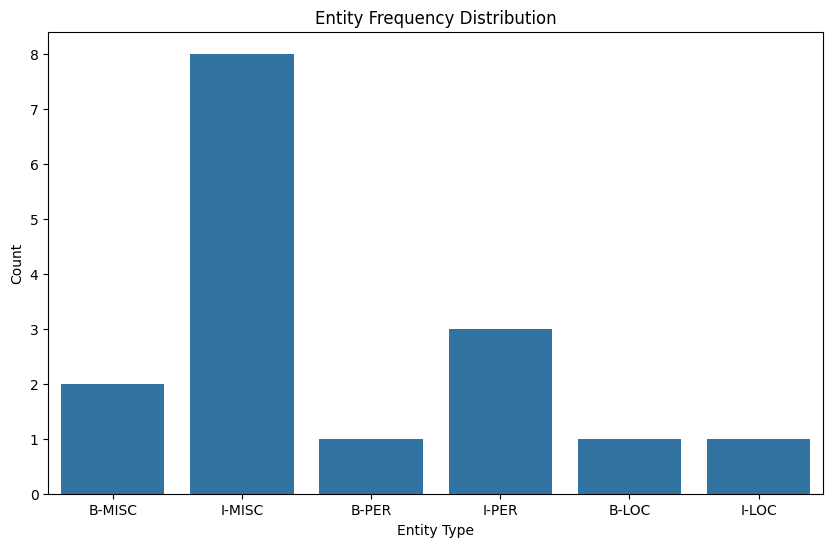

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
entities = [ent['entity'] for ent in ner_results]
entity_counts = Counter(entities)
plt.figure(figsize=(10,6))
sns.barplot(x=list(entity_counts.keys()), y=list(entity_counts.values()))
plt.title('Entity Frequency Distribution')
plt.xlabel('Entity Type')
plt.ylabel('Count')
plt.show()